<a href="https://www.kaggle.com/code/lalit7881/hyperscale-data-center-eda-100?scriptVersionId=335615724" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/deeplumiere/hyperscale-data-center-dataset/correlation_matrix.csv
/kaggle/input/datasets/deeplumiere/hyperscale-data-center-dataset/green_ai_datacenter.csv
/kaggle/input/datasets/deeplumiere/hyperscale-data-center-dataset/dataset_summary.txt
/kaggle/input/datasets/deeplumiere/hyperscale-data-center-dataset/dataset_metadata.json


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/deeplumiere/hyperscale-data-center-dataset/green_ai_datacenter.csv")

In [3]:
df.head()

,server_type,cooling_type,datacenter_region,time_of_day,maintenance_status,energy_source_primary,server_age_years,rack_u_position,workload_intensity,cpu_utilization,...,ups_battery_health,power_consumption_kw,pue,wue,carbon_intensity_gco2_kwh,renewable_energy_ratio,carbon_emission_kg,compute_cost_usd,energy_efficiency_class,failure_risk_level
0,Edge,Air,EU,Night,Normal,Solar,8,38,0.615,46.498,...,63.263,61.939,1.137,0.268,177.167,0.893,1.340,14.090,High,Medium
1,GPU,Liquid,EU,Off-Peak,Normal,Solar,2,17,0.295,21.285,...,88.992,206.840,1.050,2.353,198.353,0.723,11.935,43.436,High,Low
2,Compute,Hybrid,ME,Peak,Normal,Grid,3,1,0.683,52.201,...,78.130,96.127,1.050,0.220,444.571,0.015,44.217,10.093,Low,Low
3,Compute,Air,NaN,Off-Peak,Normal,Grid,7,39,0.416,32.406,...,66.360,100.631,1.123,0.391,328.678,0.329,24.919,16.954,Low,Medium
4,GPU,Liquid,EU,Night,Normal,Hydro,2,24,0.278,27.067,...,94.749,218.814,1.050,1.779,190.772,0.767,10.219,45.951,High,Low


In [4]:
df.tail()

,server_type,cooling_type,datacenter_region,time_of_day,maintenance_status,energy_source_primary,server_age_years,rack_u_position,workload_intensity,cpu_utilization,...,ups_battery_health,power_consumption_kw,pue,wue,carbon_intensity_gco2_kwh,renewable_energy_ratio,carbon_emission_kg,compute_cost_usd,energy_efficiency_class,failure_risk_level
99995,Edge,Air,EU,Peak,Normal,Hydro,3,21,0.867,75.254,...,89.623,78.677,1.061,0.261,200.141,0.729,4.532,16.697,High,Low
99996,GPU,Air,ME,Peak,Normal,Grid,3,17,0.712,67.259,...,81.395,327.983,1.101,0.337,448.247,0.168,134.716,36.110,Low,Medium
99997,Edge,Hybrid,APAC,Off-Peak,Normal,Grid,8,15,0.622,49.633,...,62.592,49.755,1.126,0.277,554.854,0.126,27.163,5.604,Low,Medium
99998,Compute,Air,APAC,Off-Peak,Normal,Grid,8,37,0.761,54.256,...,66.841,118.827,1.179,0.120,531.952,0.193,60.159,14.012,Low,Medium
99999,Edge,Liquid,NaN,Off-Peak,Pending,Grid,7,7,0.583,41.912,...,78.621,44.118,1.050,1.698,357.102,0.457,8.980,6.949,Medium,Medium


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   server_type                100000 non-null  object 
 1   cooling_type               100000 non-null  object 
 2   datacenter_region          71199 non-null   object 
 3   time_of_day                100000 non-null  object 
 4   maintenance_status         100000 non-null  object 
 5   energy_source_primary      100000 non-null  object 
 6   server_age_years           100000 non-null  int64  
 7   rack_u_position            100000 non-null  int64  
 8   workload_intensity         100000 non-null  float64
 9   cpu_utilization            100000 non-null  float64
 10  gpu_utilization            100000 non-null  float64
 11  memory_utilization         100000 non-null  float64
 12  storage_utilization        100000 non-null  float64
 13  disk_io_iops               100

In [6]:
df.describe()

,server_age_years,rack_u_position,workload_intensity,cpu_utilization,gpu_utilization,memory_utilization,storage_utilization,disk_io_iops,network_throughput_gbps,network_latency_ms,...,cooling_efficiency,power_supply_efficiency,ups_battery_health,power_consumption_kw,pue,wue,carbon_intensity_gco2_kwh,renewable_energy_ratio,carbon_emission_kg,compute_cost_usd
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,5.21625,21.513920,0.551330,47.170051,12.767987,56.545369,34.465213,6203.171996,15.505967,59.627713,...,0.945376,0.927837,79.050331,137.815112,1.099742,0.811080,353.354615,0.514874,28.282059,23.345205
std,3.01260,12.117263,0.259524,18.771294,23.307380,12.669366,22.080381,2559.101510,7.531797,33.432017,...,0.055436,0.030126,12.871266,90.226820,0.061745,0.766077,142.922863,0.270469,29.770134,18.013494
min,1.00000,1.000000,0.100000,7.237000,0.000000,5.000000,10.001000,1513.636000,1.267000,5.001000,...,0.835000,0.870000,40.000000,20.135000,1.050000,0.100000,118.381000,0.000000,0.000000,2.307000
25%,2.00000,11.000000,0.328000,31.495000,0.000000,47.803000,19.124750,4374.717500,10.226000,37.948000,...,0.895000,0.900000,68.676000,74.364000,1.050000,0.249000,207.896000,0.266000,7.228000,11.400000
50%,5.00000,22.000000,0.551000,47.180500,0.000000,56.570000,28.276000,5746.019500,14.139500,59.203000,...,0.960000,0.930000,79.610500,103.907000,1.061000,0.398000,345.729000,0.520000,16.265000,15.122000
75%,8.00000,32.000000,0.776000,62.937000,19.430250,65.312000,37.486000,7445.928000,19.343000,80.069000,...,1.000000,0.960000,90.012000,206.464500,1.151000,1.513000,521.486500,0.762000,45.755500,31.043500
max,11.00000,42.000000,1.000000,93.719000,100.000000,98.000000,95.000000,14461.720000,75.131000,299.987000,...,1.000000,0.970000,100.000000,935.354000,1.263000,2.500000,641.587000,1.000000,253.585000,94.717000


In [7]:
df.isnull()

,server_type,cooling_type,datacenter_region,time_of_day,maintenance_status,energy_source_primary,server_age_years,rack_u_position,workload_intensity,cpu_utilization,...,ups_battery_health,power_consumption_kw,pue,wue,carbon_intensity_gco2_kwh,renewable_energy_ratio,carbon_emission_kg,compute_cost_usd,energy_efficiency_class,failure_risk_level
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
99998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

server_type                      0
cooling_type                     0
datacenter_region            28801
time_of_day                      0
maintenance_status               0
energy_source_primary            0
server_age_years                 0
rack_u_position                  0
workload_intensity               0
cpu_utilization                  0
gpu_utilization                  0
memory_utilization               0
storage_utilization              0
disk_io_iops                     0
network_throughput_gbps          0
network_latency_ms               0
virtual_machines_count           0
ambient_temperature_c            0
humidity_percentage              0
inlet_temperature_c              0
exhaust_temperature_c            0
fan_speed_rpm                    0
airflow_cfm                      0
cooling_efficiency               0
power_supply_efficiency          0
ups_battery_health               0
power_consumption_kw             0
pue                              0
wue                 

In [9]:
df.dtypes

server_type                   object
cooling_type                  object
datacenter_region             object
time_of_day                   object
maintenance_status            object
energy_source_primary         object
server_age_years               int64
rack_u_position                int64
workload_intensity           float64
cpu_utilization              float64
gpu_utilization              float64
memory_utilization           float64
storage_utilization          float64
disk_io_iops                 float64
network_throughput_gbps      float64
network_latency_ms           float64
virtual_machines_count         int64
ambient_temperature_c        float64
humidity_percentage          float64
inlet_temperature_c          float64
exhaust_temperature_c        float64
fan_speed_rpm                float64
airflow_cfm                  float64
cooling_efficiency           float64
power_supply_efficiency      float64
ups_battery_health           float64
power_consumption_kw         float64
p

In [10]:
df.shape

(100000, 35)

In [11]:
df.columns

Index(['server_type', 'cooling_type', 'datacenter_region', 'time_of_day',
       'maintenance_status', 'energy_source_primary', 'server_age_years',
       'rack_u_position', 'workload_intensity', 'cpu_utilization',
       'gpu_utilization', 'memory_utilization', 'storage_utilization',
       'disk_io_iops', 'network_throughput_gbps', 'network_latency_ms',
       'virtual_machines_count', 'ambient_temperature_c',
       'humidity_percentage', 'inlet_temperature_c', 'exhaust_temperature_c',
       'fan_speed_rpm', 'airflow_cfm', 'cooling_efficiency',
       'power_supply_efficiency', 'ups_battery_health', 'power_consumption_kw',
       'pue', 'wue', 'carbon_intensity_gco2_kwh', 'renewable_energy_ratio',
       'carbon_emission_kg', 'compute_cost_usd', 'energy_efficiency_class',
       'failure_risk_level'],
      dtype='object')

In [12]:
df.nunique()

server_type                      4
cooling_type                     3
datacenter_region                3
time_of_day                      3
maintenance_status               3
energy_source_primary            4
server_age_years                11
rack_u_position                 42
workload_intensity             901
cpu_utilization              53307
gpu_utilization              22592
memory_utilization           43530
storage_utilization          42157
disk_io_iops                 99387
network_throughput_gbps      28426
network_latency_ms           60781
virtual_machines_count          90
ambient_temperature_c        29221
humidity_percentage          39519
inlet_temperature_c           5972
exhaust_temperature_c        20096
fan_speed_rpm                65364
airflow_cfm                  62770
cooling_efficiency              18
power_supply_efficiency         11
ups_battery_health           40543
power_consumption_kw         77403
pue                            214
wue                 

## EDA


In [13]:
# Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [14]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 100000
Columns : 35


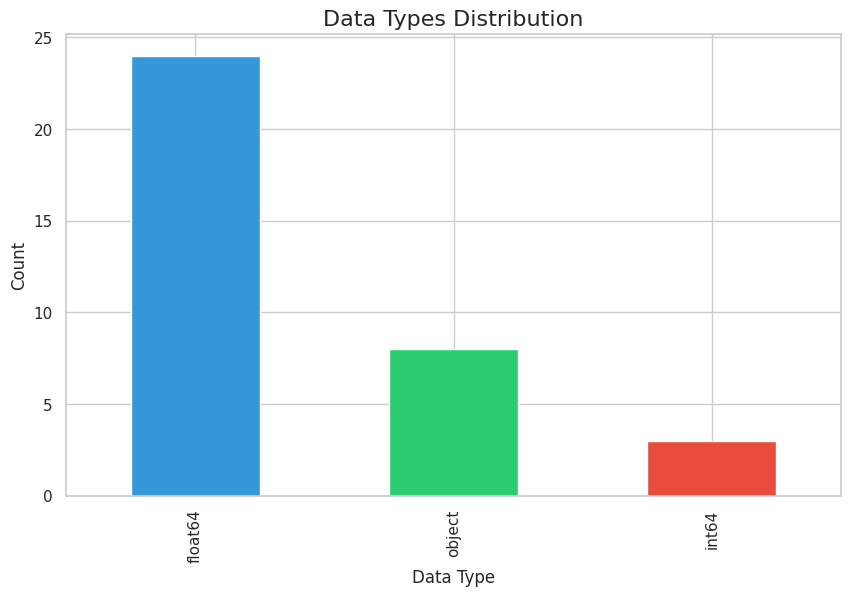

In [15]:
plt.figure(figsize=(10,6))

df.dtypes.value_counts().plot(
    kind='bar',
    color=['#3498db','#2ecc71','#e74c3c']
)

plt.title("Data Types Distribution",fontsize=16)
plt.xlabel("Data Type")
plt.ylabel("Count")
plt.show()

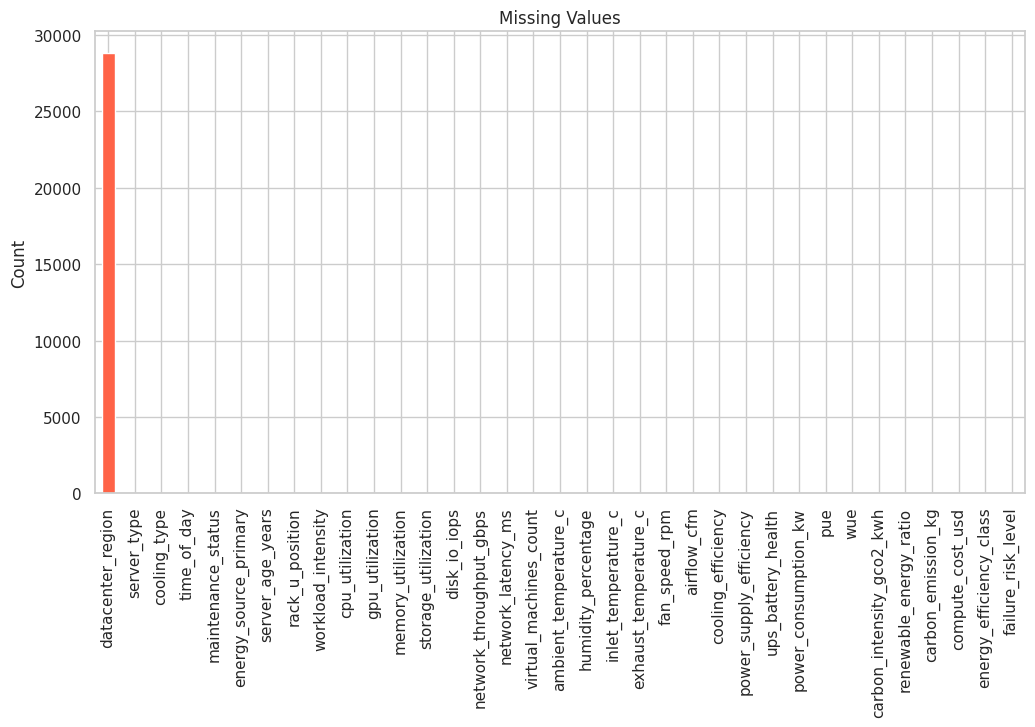

In [16]:
missing=df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))

missing.plot(
    kind='bar',
    color='tomato'
)

plt.title("Missing Values")
plt.ylabel("Count")
plt.show()

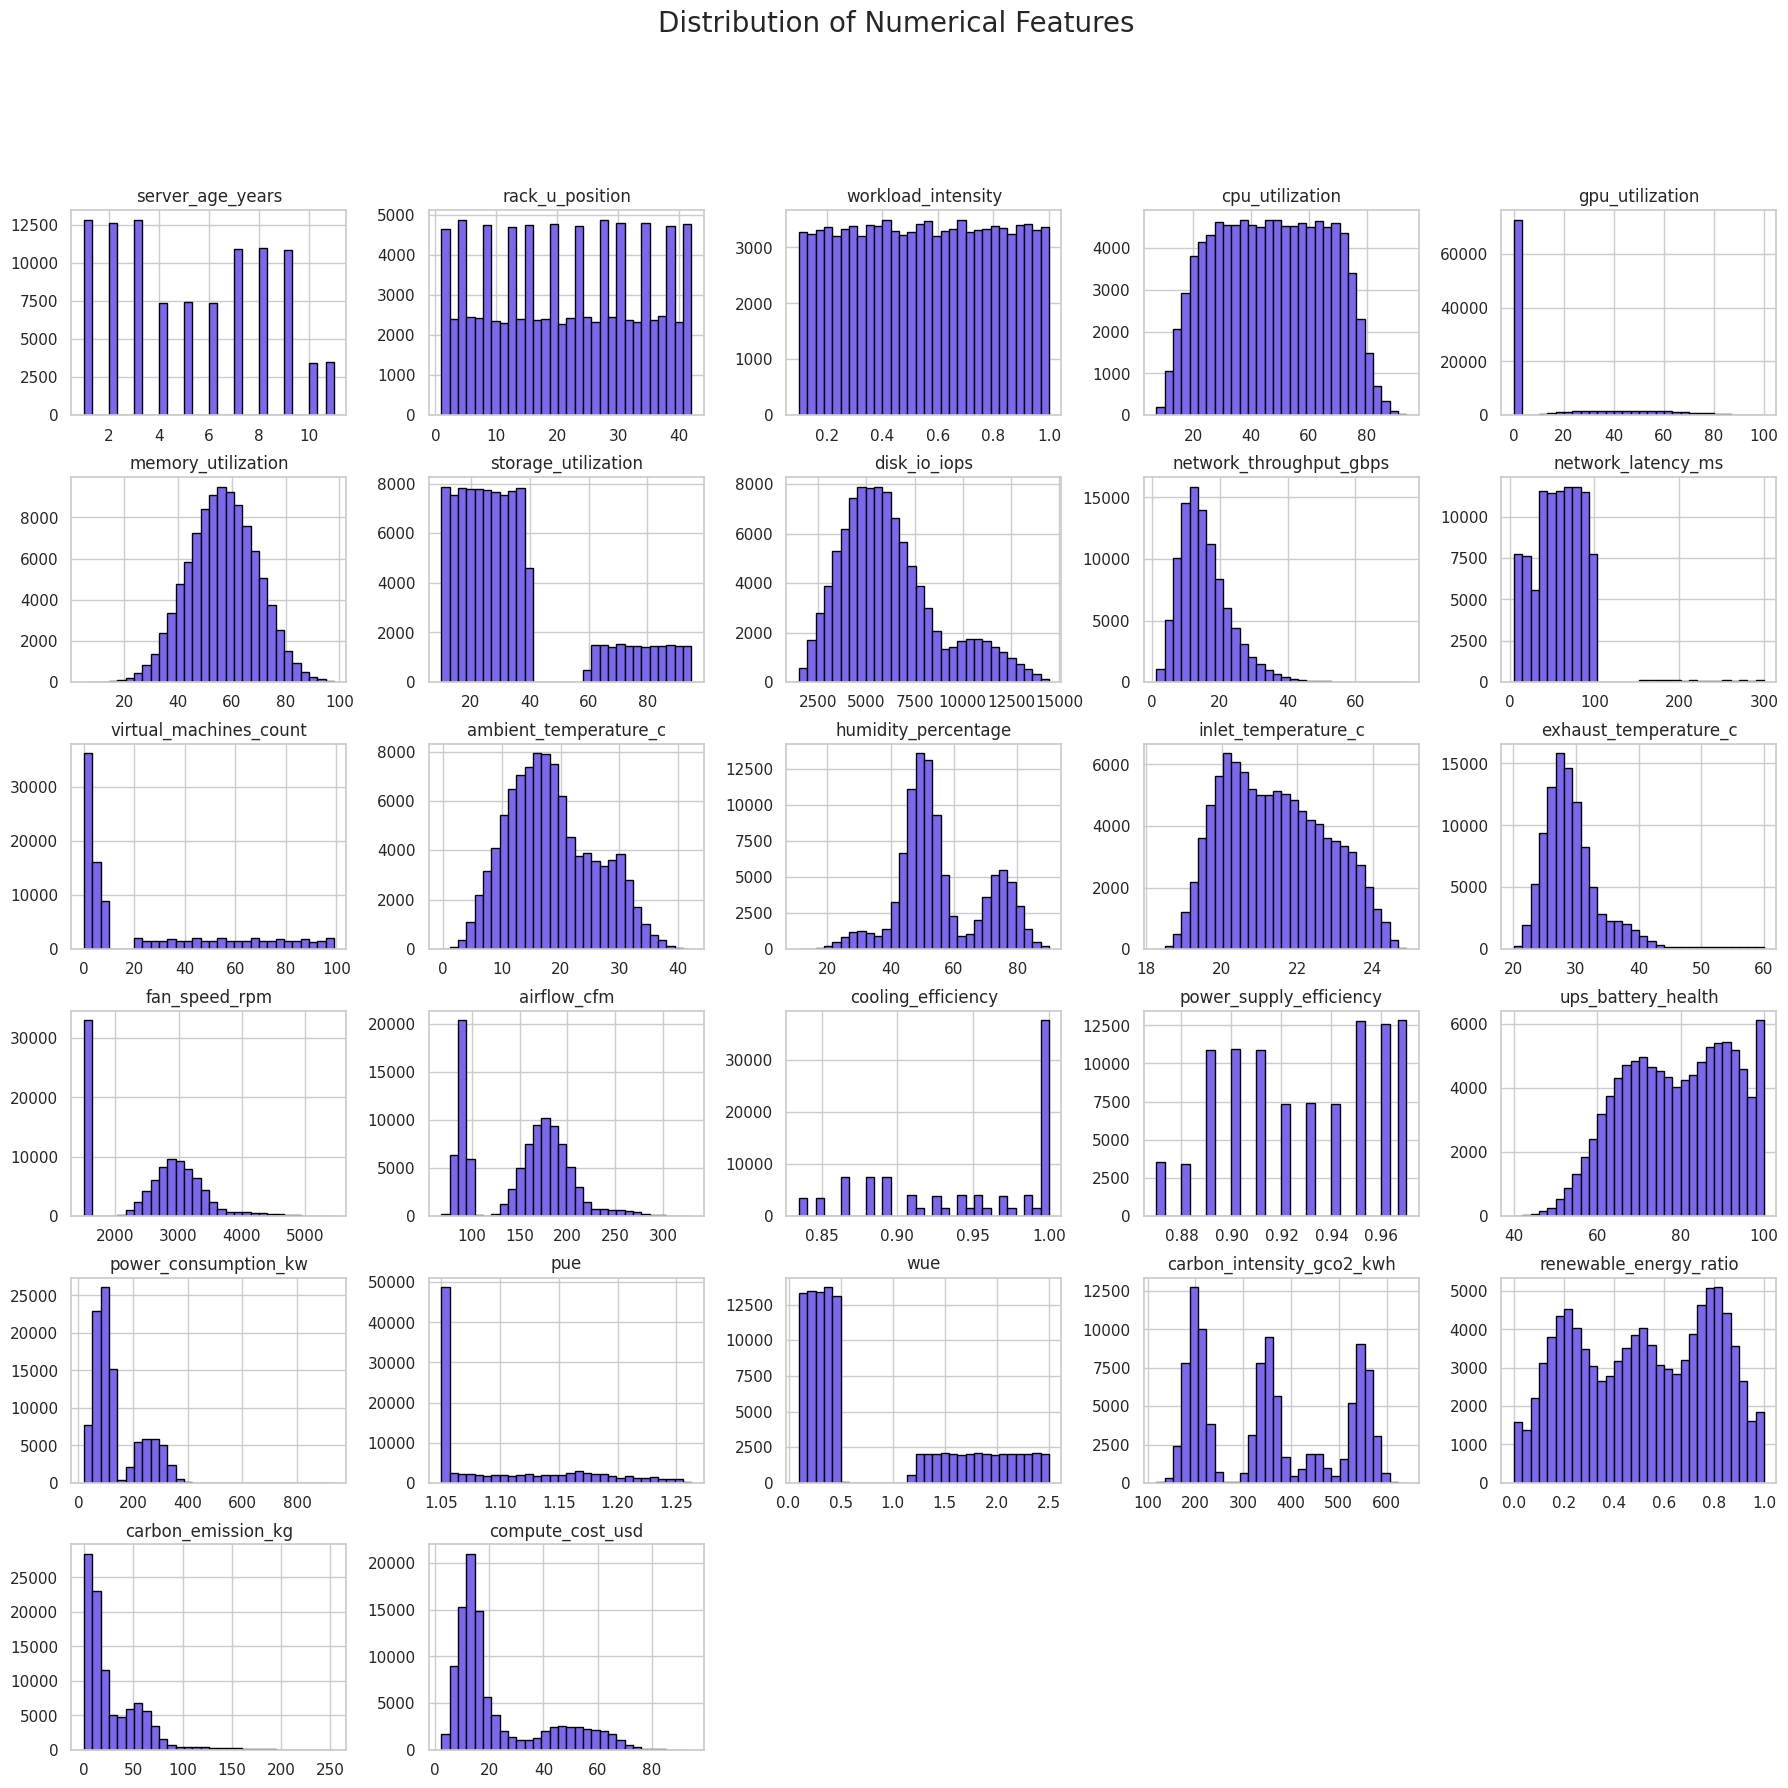

In [17]:
num_cols=df.select_dtypes(include=np.number).columns

df[num_cols].hist(
    figsize=(22,20),
    bins=30,
    color='mediumslateblue',
    edgecolor='black'
)

plt.suptitle("Distribution of Numerical Features",fontsize=20)
plt.show()

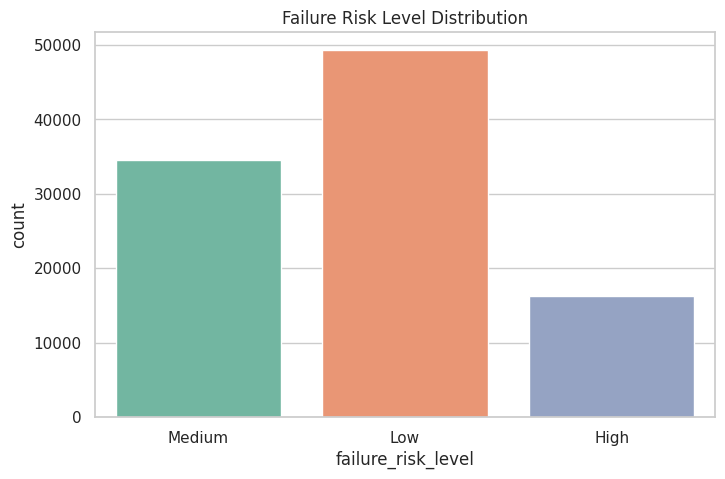

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='failure_risk_level',
    data=df,
    palette='Set2'
)

plt.title("Failure Risk Level Distribution")
plt.show()

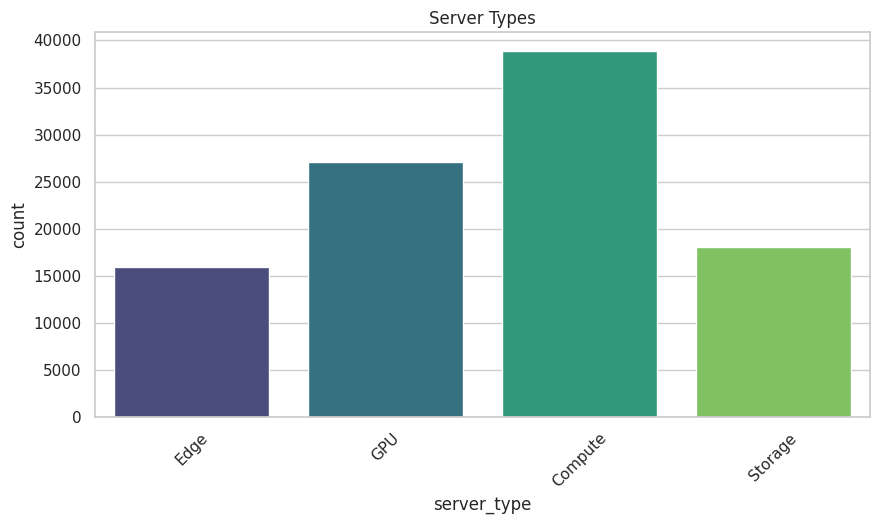

In [19]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='server_type',
    data=df,
    palette='viridis'
)

plt.xticks(rotation=45)
plt.title("Server Types")
plt.show()

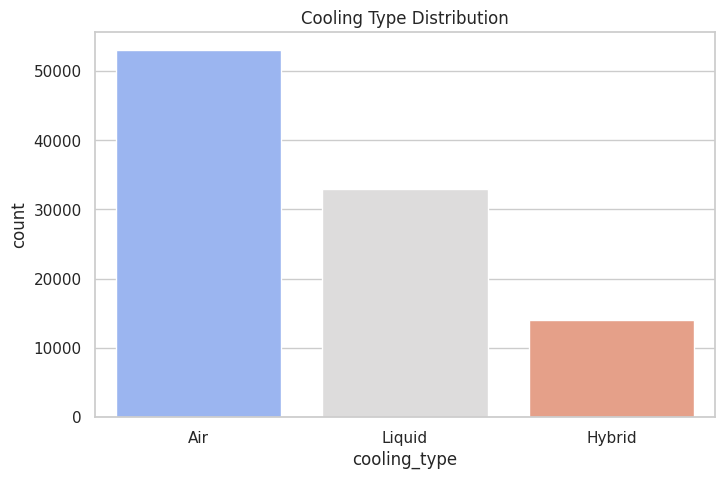

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='cooling_type',
    data=df,
    palette='coolwarm'
)

plt.title("Cooling Type Distribution")
plt.show()

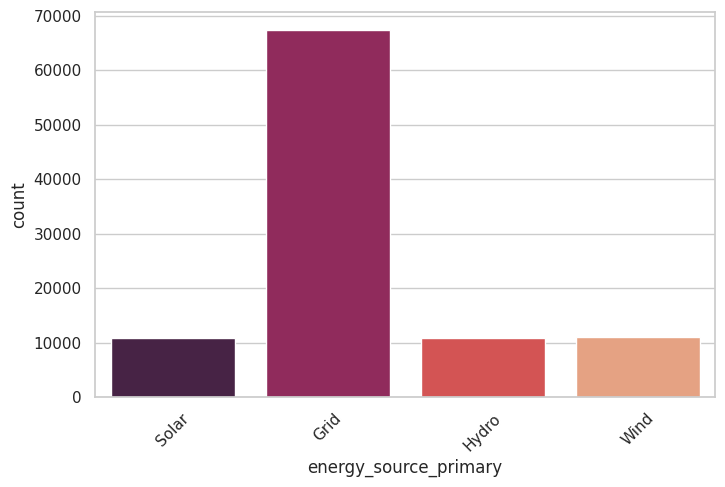

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='energy_source_primary',
    data=df,
    palette='rocket'
)

plt.xticks(rotation=45)
plt.show()

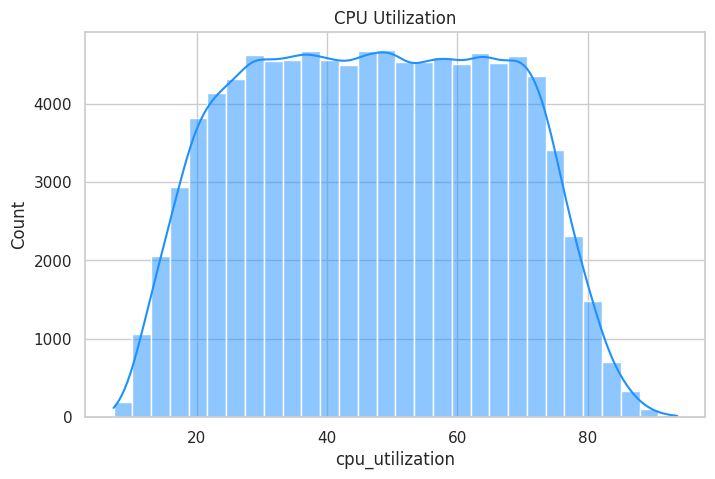

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['cpu_utilization'],
    bins=30,
    kde=True,
    color='dodgerblue'
)

plt.title("CPU Utilization")
plt.show()

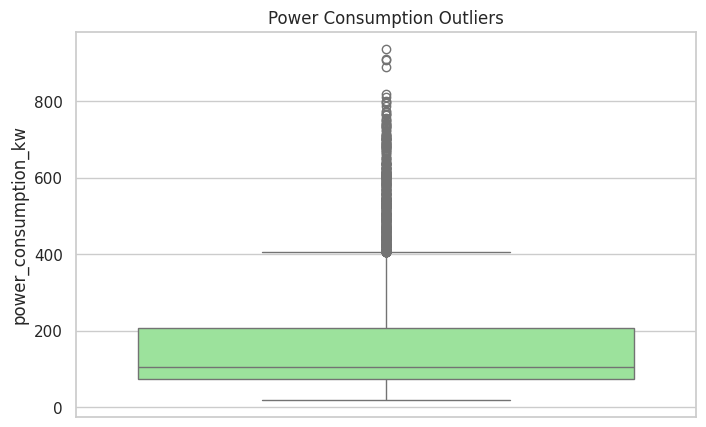

In [23]:
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df['power_consumption_kw'],
    color='lightgreen'
)

plt.title("Power Consumption Outliers")
plt.show()

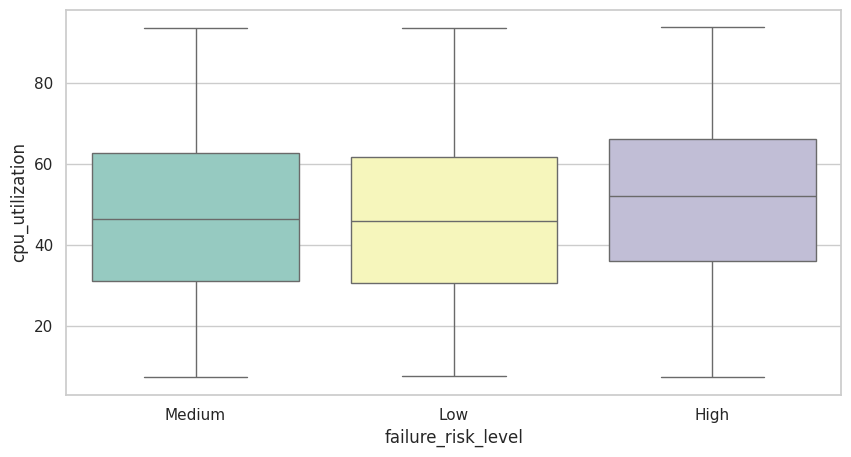

In [24]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x='failure_risk_level',
    y='cpu_utilization',
    data=df,
    palette='Set3'
)

plt.show()

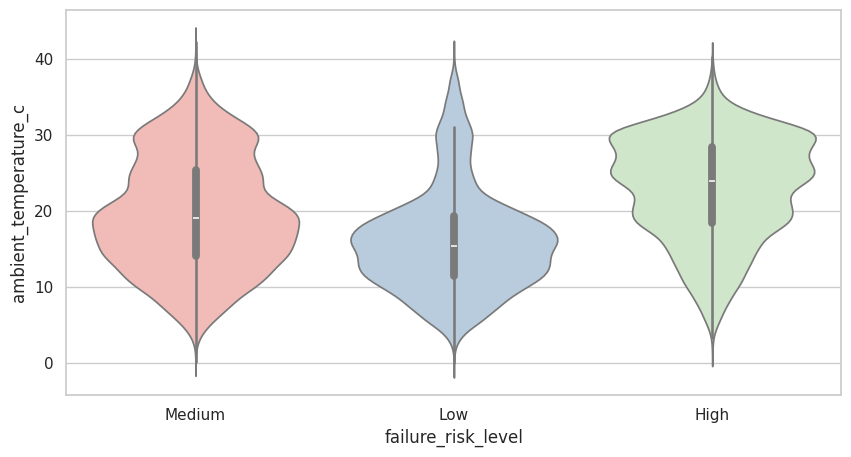

In [25]:
plt.figure(figsize=(10,5))

sns.violinplot(
    x='failure_risk_level',
    y='ambient_temperature_c',
    data=df,
    palette='Pastel1'
)

plt.show()

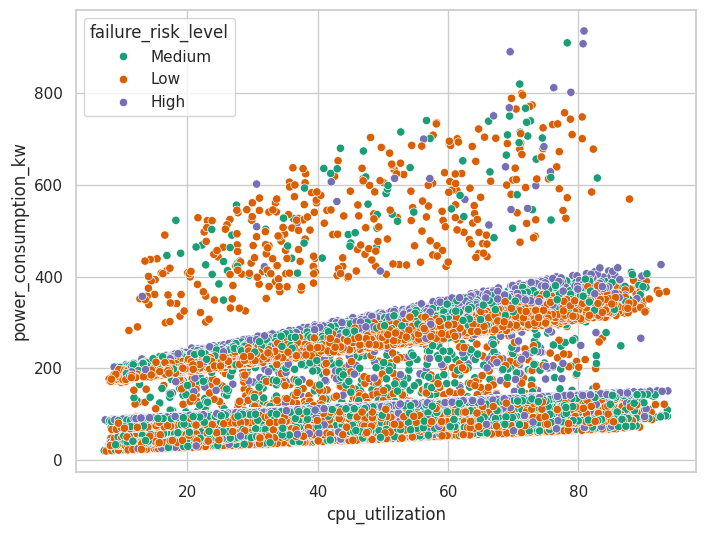

In [26]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='cpu_utilization',
    y='power_consumption_kw',
    hue='failure_risk_level',
    palette='Dark2',
    data=df
)

plt.show()

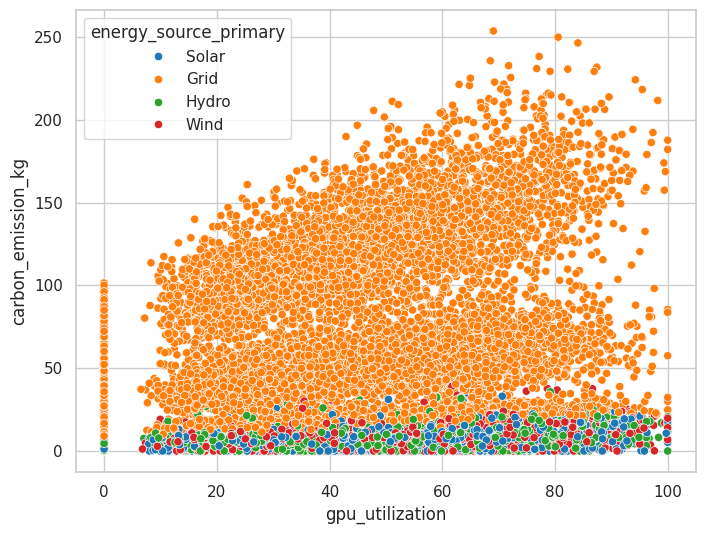

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='gpu_utilization',
    y='carbon_emission_kg',
    hue='energy_source_primary',
    palette='tab10',
    data=df
)

plt.show()

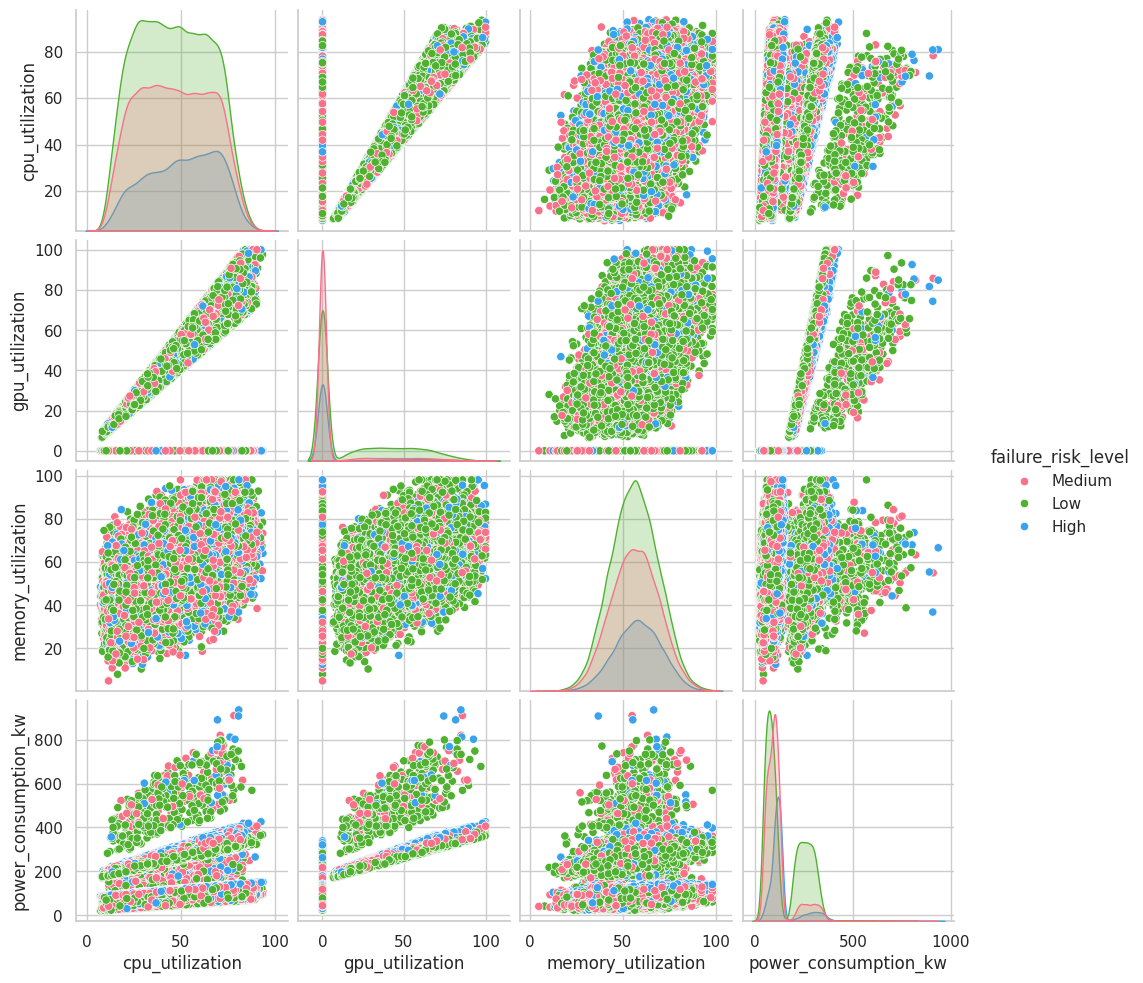

In [28]:
sns.pairplot(
    df[['cpu_utilization',
        'gpu_utilization',
        'memory_utilization',
        'power_consumption_kw',
        'failure_risk_level']],
    hue='failure_risk_level',
    palette='husl'
)

plt.show()

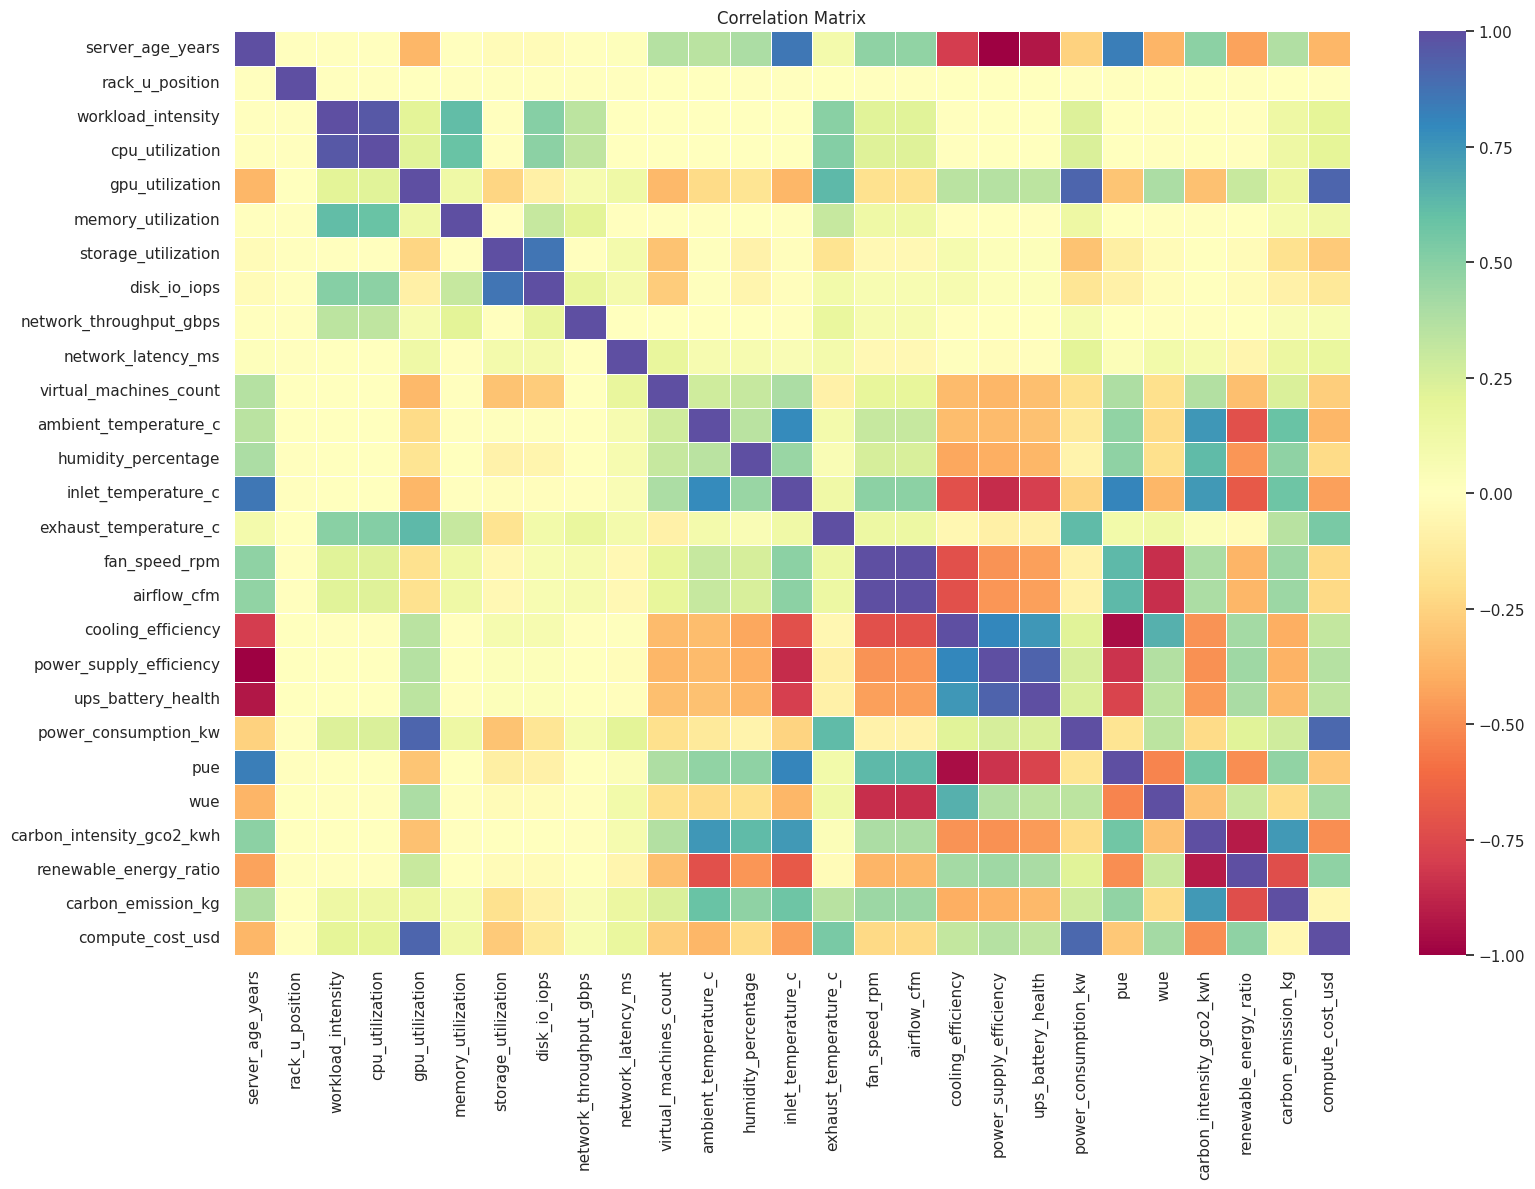

In [29]:
plt.figure(figsize=(18,12))

corr=df[num_cols].corr()

sns.heatmap(
    corr,
    cmap='Spectral',
    annot=False,
    linewidths=.5
)

plt.title("Correlation Matrix")
plt.show()

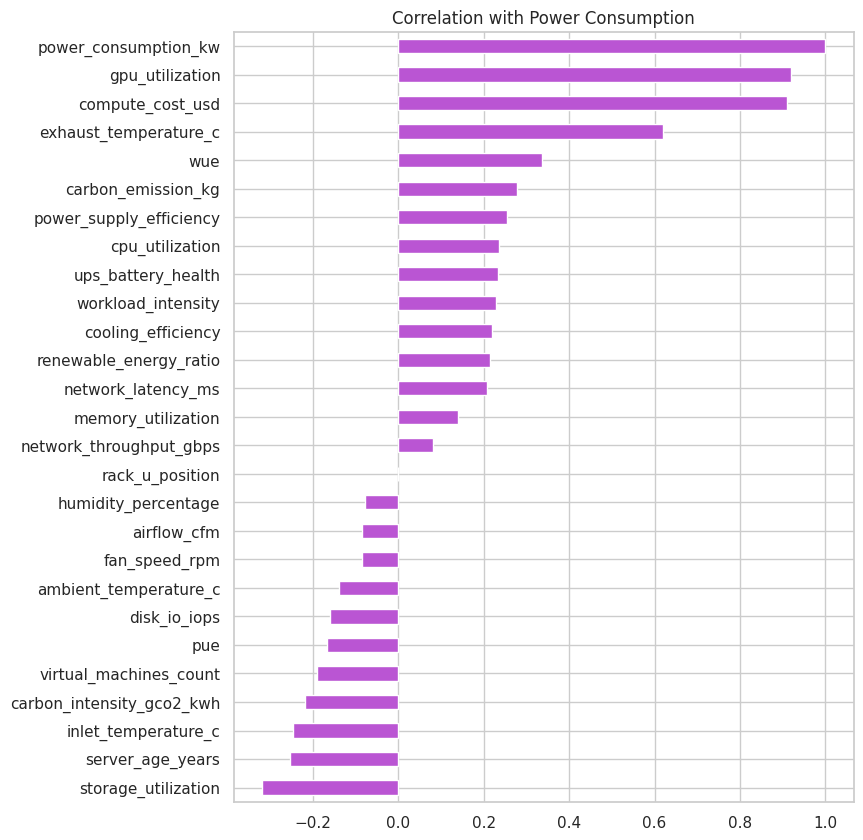

In [30]:
corr_target=corr['power_consumption_kw'].sort_values()

plt.figure(figsize=(8,10))

corr_target.plot(
    kind='barh',
    color='mediumorchid'
)

plt.title("Correlation with Power Consumption")
plt.show()

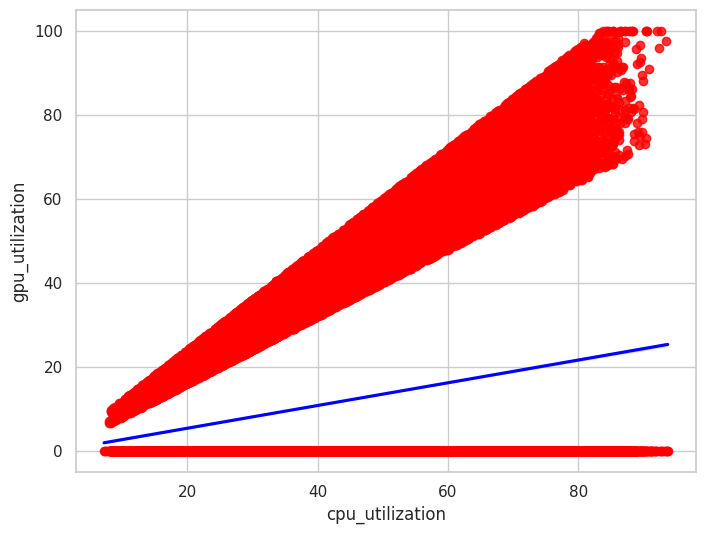

In [31]:
plt.figure(figsize=(8,6))

sns.regplot(
    x='cpu_utilization',
    y='gpu_utilization',
    data=df,
    scatter_kws={'color':'red'},
    line_kws={'color':'blue'}
)

plt.show()

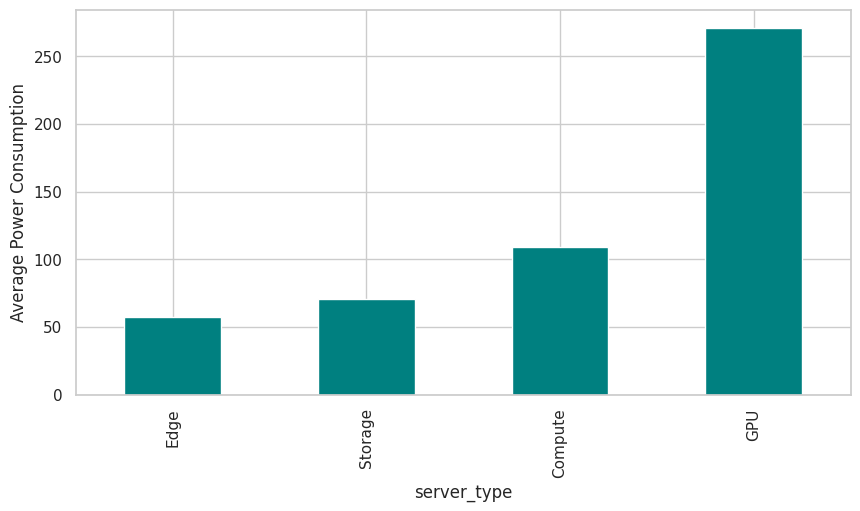

In [32]:
plt.figure(figsize=(10,5))

df.groupby('server_type')['power_consumption_kw'].mean().sort_values().plot(
    kind='bar',
    color='teal'
)

plt.ylabel("Average Power Consumption")
plt.show()

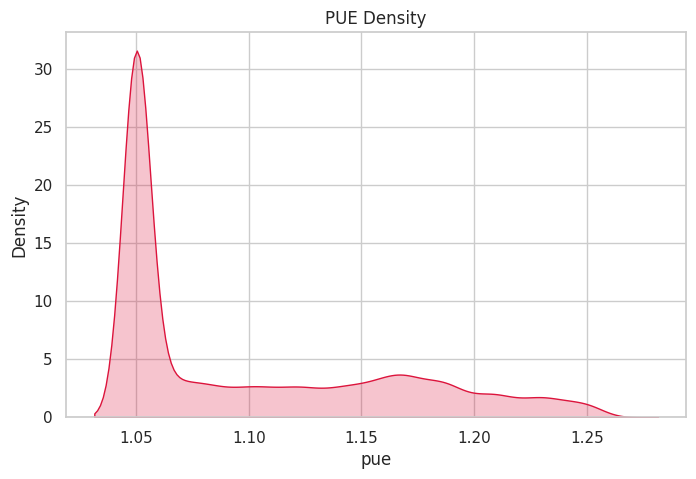

In [33]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df['pue'],
    fill=True,
    color='crimson'
)

plt.title("PUE Density")
plt.show()

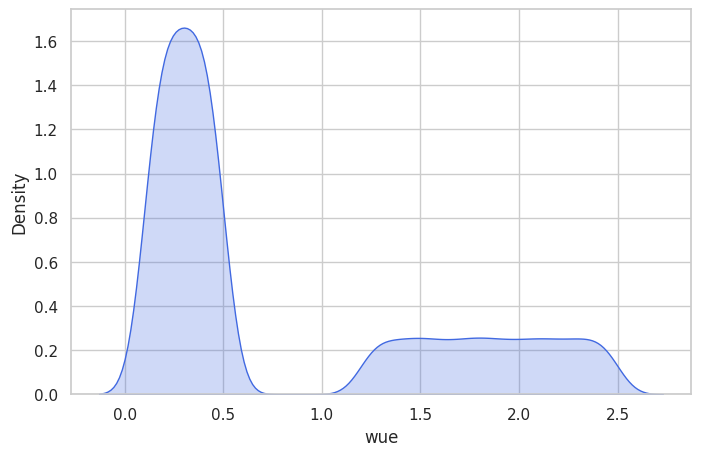

In [34]:
plt.figure(figsize=(8,5))

sns.kdeplot(
    df['wue'],
    fill=True,
    color='royalblue'
)

plt.show()

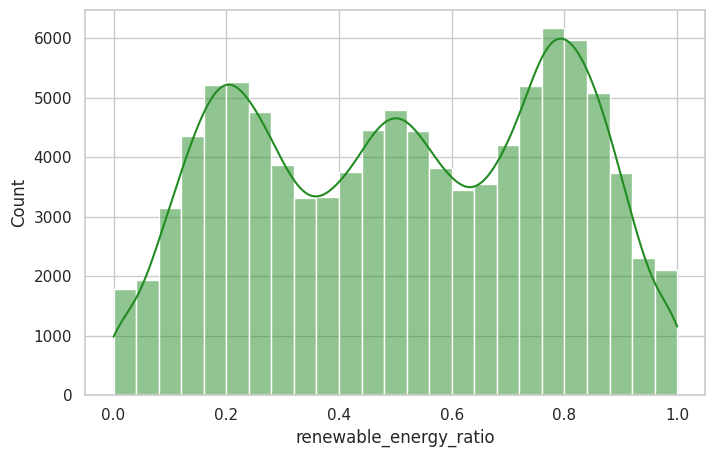

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['renewable_energy_ratio'],
    bins=25,
    color='forestgreen',
    kde=True
)

plt.show()

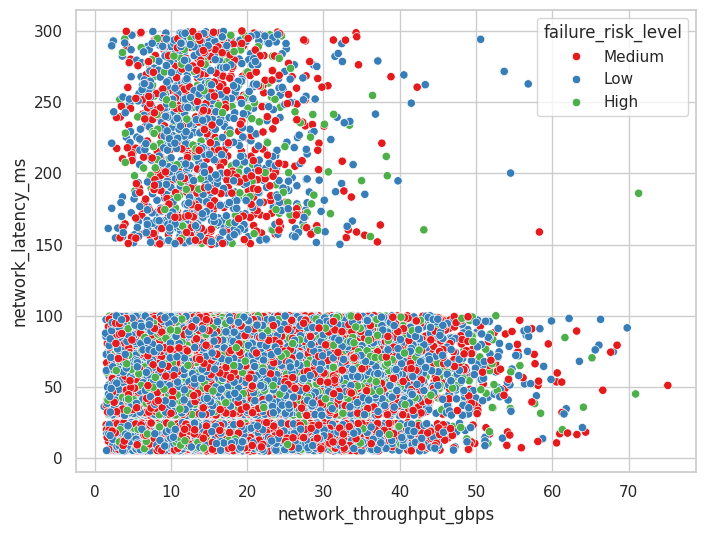

In [36]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='network_throughput_gbps',
    y='network_latency_ms',
    hue='failure_risk_level',
    palette='Set1',
    data=df
)

plt.show()

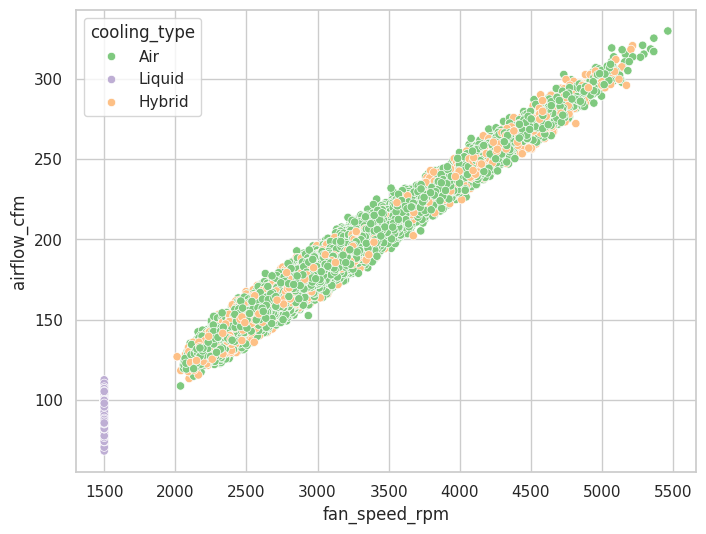

In [37]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='fan_speed_rpm',
    y='airflow_cfm',
    hue='cooling_type',
    palette='Accent',
    data=df
)

plt.show()

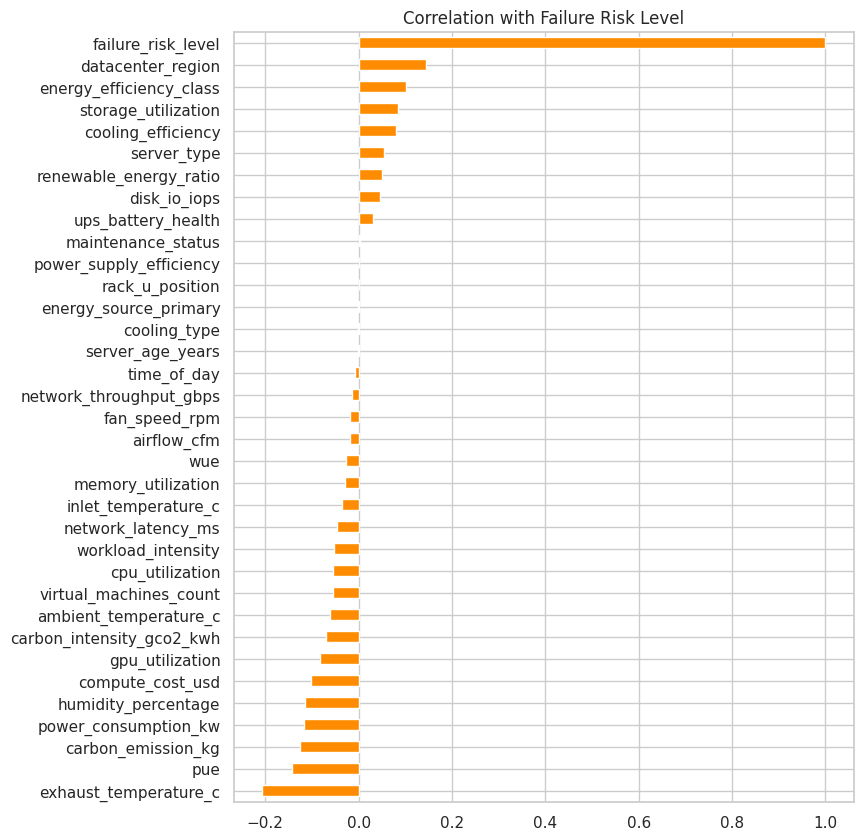

In [38]:
from sklearn.preprocessing import LabelEncoder

temp=df.copy()

for col in temp.select_dtypes(include='object').columns:
    temp[col]=LabelEncoder().fit_transform(temp[col])

corr=temp.corr()['failure_risk_level'].sort_values()

plt.figure(figsize=(8,10))

corr.plot(
    kind='barh',
    color='darkorange'
)

plt.title("Correlation with Failure Risk Level")
plt.show()

## Feature engineering

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [40]:
df.fillna(method="ffill", inplace=True)

In [41]:
label_encoders = {}

categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

In [42]:
X = df.drop("failure_risk_level", axis=1)

y = df["failure_risk_level"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (80000, 34)
Testing Shape : (20000, 34)


In [44]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [45]:
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from xgboost import XGBClassifier

In [46]:
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "KNN":
        KNeighborsClassifier(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Extra Trees":
        ExtraTreesClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "AdaBoost":
        AdaBoostClassifier(random_state=42),

    "Naive Bayes":
        GaussianNB(),

    "Support Vector Machine":
        SVC(),

    "XGBoost":
        XGBClassifier(
            eval_metric="mlogloss",
            random_state=42
        )
}

In [47]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    results.append([
        name,
        accuracy * 100,
        precision * 100,
        recall * 100,
        f1 * 100
    ])

    print("="*60)

    print(name)

    print("="*60)

    print(f"Accuracy : {accuracy*100:.2f}%")

    print(f"Precision : {precision*100:.2f}%")

    print(f"Recall : {recall*100:.2f}%")

    print(f"F1 Score : {f1*100:.2f}%")

    print("\nClassification Report\n")

    print(classification_report(y_test,y_pred))

    print("\nConfusion Matrix\n")

    print(confusion_matrix(y_test,y_pred))

Logistic Regression
Accuracy : 99.52%
Precision : 99.52%
Recall : 99.52%
F1 Score : 99.52%

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3254
           1       1.00      1.00      1.00      9850
           2       0.99      0.99      0.99      6896

    accuracy                           1.00     20000
   macro avg       0.99      0.99      0.99     20000
weighted avg       1.00      1.00      1.00     20000


Confusion Matrix

[[3219    1   34]
 [   0 9834   16]
 [  37    8 6851]]
KNN
Accuracy : 91.77%
Precision : 91.84%
Recall : 91.77%
F1 Score : 91.70%

Classification Report

              precision    recall  f1-score   support

           0       0.92      0.79      0.85      3254
           1       0.96      0.97      0.96      9850
           2       0.86      0.91      0.88      6896

    accuracy                           0.92     20000
   macro avg       0.91      0.89      0.90     20000
weigh

In [48]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy %",
        "Precision %",
        "Recall %",
        "F1 Score %"
    ]
)

results_df = results_df.sort_values(
    by="Accuracy %",
    ascending=False
)

results_df

,Model,Accuracy %,Precision %,Recall %,F1 Score %
9,XGBoost,99.535,99.535189,99.535,99.535058
0,Logistic Regression,99.520,99.520263,99.520,99.520119
5,Gradient Boosting,99.290,99.289662,99.290,99.289636
2,Decision Tree,99.225,99.225428,99.225,99.225180
3,Random Forest,99.055,99.055432,99.055,99.054746
8,Support Vector Machine,98.810,98.808205,98.810,98.808710
4,Extra Trees,97.990,97.986581,97.990,97.987850
6,AdaBoost,93.060,93.355374,93.060,93.081888
1,KNN,91.775,91.841290,91.775,91.704215
7,Naive Bayes,81.930,82.770020,81.930,82.172510


In [49]:
print(results_df.iloc[0])

Model            XGBoost
Accuracy %        99.535
Precision %    99.535189
Recall %          99.535
F1 Score %     99.535058
Name: 9, dtype: object


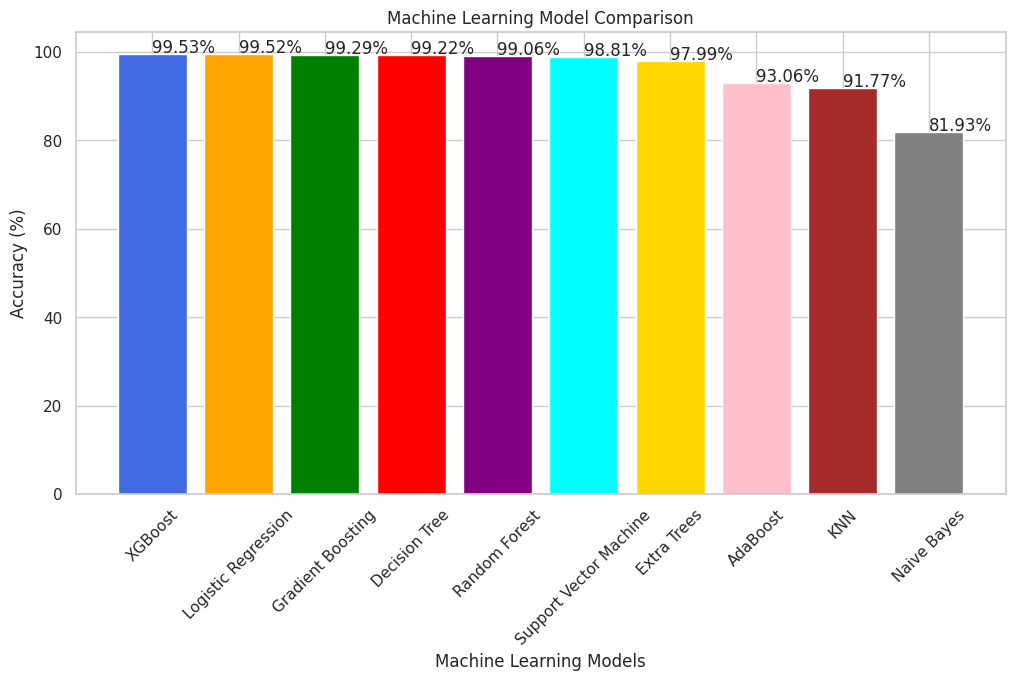

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy %"],
    color=[
        "royalblue",
        "orange",
        "green",
        "red",
        "purple",
        "cyan",
        "gold",
        "pink",
        "brown",
        "gray"
    ]
)

plt.xticks(rotation=45)

plt.ylabel("Accuracy (%)")

plt.xlabel("Machine Learning Models")

plt.title("Machine Learning Model Comparison")

for i,v in enumerate(results_df["Accuracy %"]):
    plt.text(i,v+0.3,f"{v:.2f}%")

plt.show()

In [51]:
results_df.style.background_gradient(cmap="viridis")

,Model,Accuracy %,Precision %,Recall %,F1 Score %
9,XGBoost,99.535000,99.535189,99.535000,99.535058
0,Logistic Regression,99.520000,99.520263,99.520000,99.520119
5,Gradient Boosting,99.290000,99.289662,99.290000,99.289636
2,Decision Tree,99.225000,99.225428,99.225000,99.225180
3,Random Forest,99.055000,99.055432,99.055000,99.054746
8,Support Vector Machine,98.810000,98.808205,98.810000,98.808710
4,Extra Trees,97.990000,97.986581,97.990000,97.987850
6,AdaBoost,93.060000,93.355374,93.060000,93.081888
1,KNN,91.775000,91.841290,91.775000,91.704215
7,Naive Bayes,81.930000,82.770020,81.930000,82.172510


## Thank you..pls upvote!!!!!!!!!!!!